# OmniHD PointPillars: LiDAR vs 4D RADAR on TruckScenes

This notebook compares OmniHD-pretrained PointPillars models transferred to TruckScenes without retraining: one using LiDAR and one using 4D RADAR. Both use the same TruckScenes samples and ground truth, with mapped classes **car**, **pedestrian**, **rider**, and **large_vehicle**.

The operating point is confidence score **≥ 0.5** and XY centre-distance match **< 2 m**. Official AP is evaluated at centre-distance thresholds of **1 m, 2 m, 3 m, and 4 m**.

**Caveat:** results reflect both sensor modality and domain-transfer/model effects; they are not pure intrinsic sensor-performance measurements.

In [1]:
from pathlib import Path
import json, numpy as np, pandas as pd, matplotlib.pyplot as plt
from IPython.display import display, Markdown
RADAR_METRICS_PATH=Path("radar_trainval_135_metrics.json")
LIDAR_METRICS_PATH=Path("lidar_trainval_135_metrics.json")
COMPLEMENTARITY_PATH=Path("lidar_radar_trainval_135_complementarity.json")
with RADAR_METRICS_PATH.open(encoding="utf-8") as f: radar=json.load(f)
with LIDAR_METRICS_PATH.open(encoding="utf-8") as f: lidar=json.load(f)
with COMPLEMENTARITY_PATH.open(encoding="utf-8") as f: comp=json.load(f)
metrics={"LiDAR":lidar,"RADAR":radar}; classes=["car","pedestrian","rider","large_vehicle"]
def plot_grouped(labels, vals, title, ylabel, pct=False):
    x=np.arange(len(labels)); w=.38; fig,ax=plt.subplots()
    for i,(name,v) in enumerate(vals.items()):
        v=[np.nan if z is None else z for z in v]; v=[z*100 if pct and not pd.isna(z) else z for z in v]
        ax.bar(x+(i-.5)*w,v,w,label=name)
    ax.set_xticks(x,labels); ax.set_title(title); ax.set_ylabel(ylabel); ax.legend(); fig.tight_layout(); plt.show()
def plot_single(labels, vals, title, ylabel, pct=False):
    v=[np.nan if z is None else z for z in vals]; v=[z*100 if pct and not pd.isna(z) else z for z in v]
    fig,ax=plt.subplots(); bars=ax.bar(labels,v); ax.set_title(title); ax.set_ylabel(ylabel)
    for b,z in zip(bars,v):
        if not pd.isna(z): ax.text(b.get_x()+b.get_width()/2,b.get_height(),f"{z:.1f}{'%' if pct else ''}",ha="center",va="bottom")
    fig.tight_layout(); plt.show()
def condition_table(section, keys, container, fields, labels=None):
    labels=labels or keys; rows=[]
    for k,label in zip(keys,labels):
        r={"condition":label}
        for mod,d in metrics.items():
            item=d[section][container][k]
            for f in fields: r[f"{mod} {f}"]=item.get(f)
        rows.append(r)
    return pd.DataFrame(rows)
def fmt(df):
    return df.style.format({c:"{:.1%}" for c in df.columns if any(x in c.lower() for x in ["map","precision","recall","f1","rate"])}|{c:"{:.3f}" for c in df.columns if "ate" in c.lower() or "aoe" in c.lower() or c=="ASE"})

## 1. Experiment Overview
Two OmniHD-pretrained PointPillars models are transferred to TruckScenes without retraining: one LiDAR model and one 4D RADAR model. The evaluation uses the same samples and GT for both modalities. Four mapped classes are used: car, pedestrian, rider, and large_vehicle.

## 2. Overall Detection Performance

,modality,mAP,predictions,TP,FP,FN,precision,recall,F1,ATE (m),ASE,AOE (rad)
0,LiDAR,17.5%,42801,34310,8491,53471,80.2%,39.1%,52.5%,0.442,0.242,0.153
1,RADAR,0.6%,9487,3414,6073,84367,36.0%,3.9%,7.0%,1.024,0.314,0.054


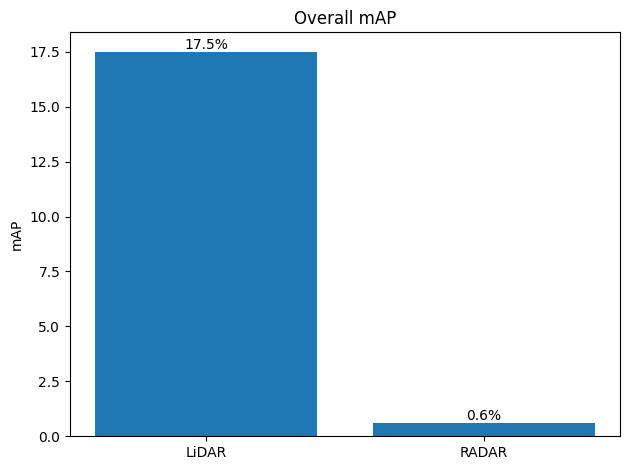

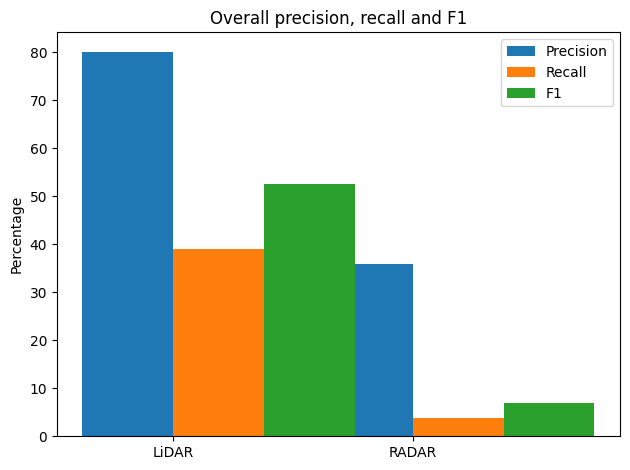

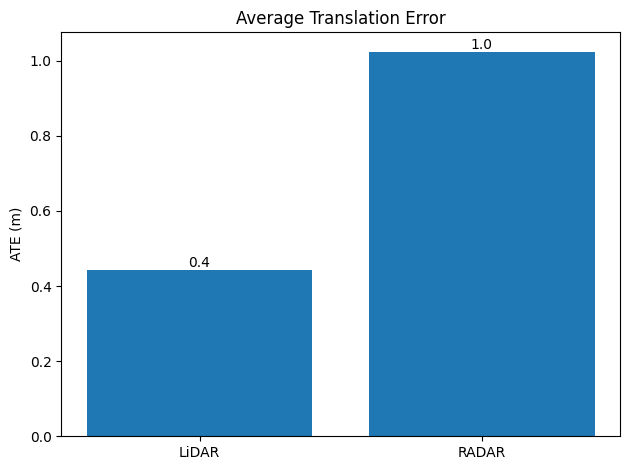

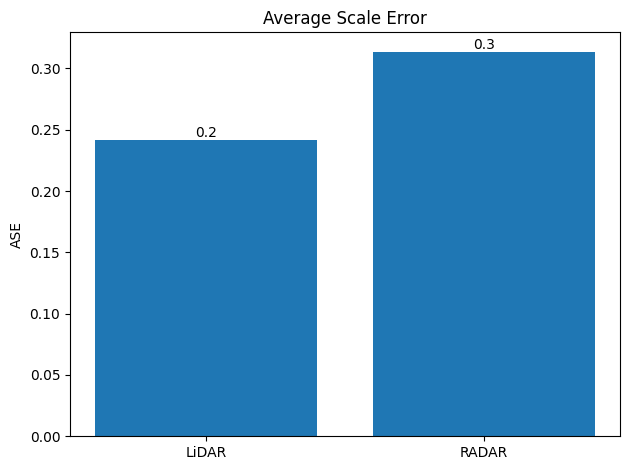

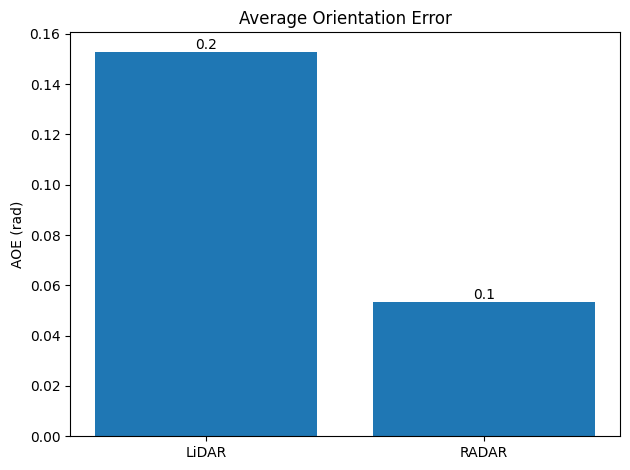

In [2]:
rows=[]
for mod,d in metrics.items():
    o=d["overall_metrics"]["operating_point"]
    rows.append({"modality":mod,"mAP":d["mAP"],"predictions":o["prediction_count"],"TP":o["tp"],"FP":o["fp"],"FN":o["fn"],"precision":o["precision"],"recall":o["recall"],"F1":o["f1_score"],"ATE (m)":o["ate_m"],"ASE":o["ase"],"AOE (rad)":o["aoe_rad"]})
overall_df=pd.DataFrame(rows); display(fmt(overall_df))
plot_single(list(overall_df.modality),list(overall_df["mAP"]),"Overall mAP","mAP",True)
plot_grouped(list(overall_df.modality),{"Precision":list(overall_df.precision),"Recall":list(overall_df.recall),"F1":list(overall_df.F1)},"Overall precision, recall and F1","Percentage",True)
for c,t,y in [("ATE (m)","Average Translation Error","ATE (m)"),("ASE","Average Scale Error","ASE"),("AOE (rad)","Average Orientation Error","AOE (rad)")]: plot_single(list(overall_df.modality),list(overall_df[c]),t,y)

LiDAR substantially outperforms RADAR as a standalone detector under this transfer setup. ATE, ASE, and AOE are shown separately because they use different units.

## 3. Performance by Class

,class,LiDAR mean AP,LiDAR precision,LiDAR recall,LiDAR F1,LiDAR ATE (m),RADAR mean AP,RADAR precision,RADAR recall,RADAR F1,RADAR ATE (m)
0,car,0.664945,90.1%,52.4%,66.3%,0.416,0.022509,60.2%,3.9%,7.3%,1.014
1,pedestrian,0.000000,0.0%,0.0%,0.0%,nan,0.000000,nan%,0.0%,nan%,nan
2,rider,0.000000,14.3%,0.4%,0.7%,0.391,0.000000,0.0%,0.0%,0.0%,nan
3,large_vehicle,0.035289,31.4%,10.7%,16.0%,0.817,0.002552,18.7%,4.9%,7.8%,1.048


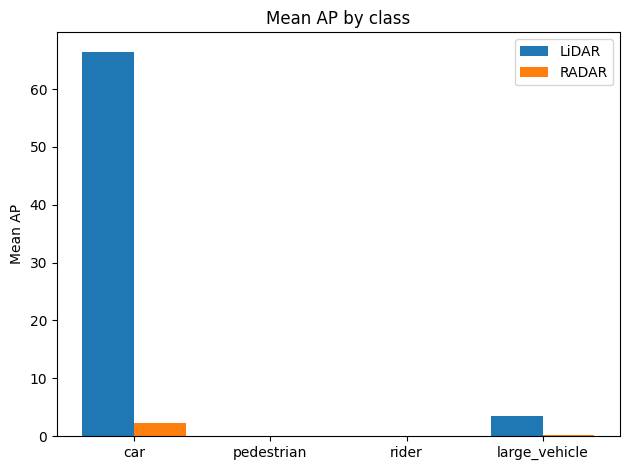

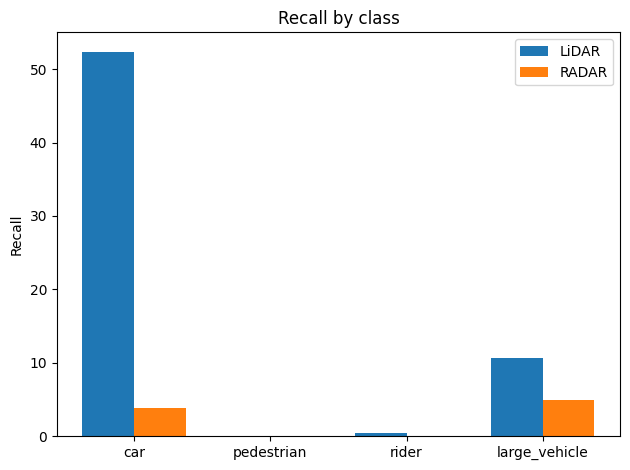

In [3]:
rows=[]
for cls in classes:
    r={"class":cls}
    for mod,d in metrics.items():
        x=d["class_metrics"][cls]; o=x["operating_point"]
        r.update({f"{mod} mean AP":x["mean_ap"],f"{mod} precision":o["precision"],f"{mod} recall":o["recall"],f"{mod} F1":o["f1_score"],f"{mod} ATE (m)":o["ate_m"]})
    rows.append(r)
class_df=pd.DataFrame(rows); display(fmt(class_df))
plot_grouped(classes,{"LiDAR":list(class_df["LiDAR mean AP"]),"RADAR":list(class_df["RADAR mean AP"])},"Mean AP by class","Mean AP",True)
plot_grouped(classes,{"LiDAR":list(class_df["LiDAR recall"]),"RADAR":list(class_df["RADAR recall"])},"Recall by class","Recall",True)

LiDAR car detection is by far the strongest result. Large vehicles remain challenging, particularly for RADAR, and pedestrian/rider performance is extremely poor for both. Avoid over-interpreting classes with very few true positives.

## 4. AP by Matching Distance

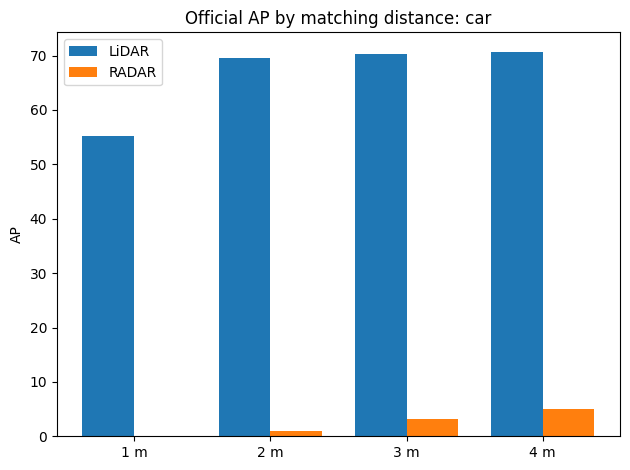

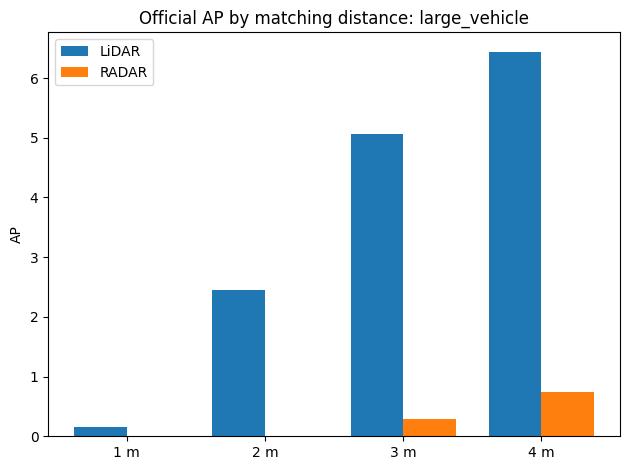

In [4]:
ap=[]
for cls in classes:
    for th in ["1.0","2.0","3.0","4.0"]:
        ap.append({"class":cls,"threshold (m)":float(th),"LiDAR":lidar["class_metrics"][cls]["ap_by_distance_threshold"][th],"RADAR":radar["class_metrics"][cls]["ap_by_distance_threshold"][th]})
ap_df=pd.DataFrame(ap); display(ap_df.pivot(index="class",columns="threshold (m)",values=["LiDAR","RADAR"]).style.format("{:.1%}"))
for cls in ["car","large_vehicle"]:
    s=ap_df[ap_df["class"]==cls]; plot_grouped(["1 m","2 m","3 m","4 m"],{"LiDAR":list(s.LiDAR),"RADAR":list(s.RADAR)},f"Official AP by matching distance: {cls}","AP",True)

## 5. Performance by Object Distance

,condition,LiDAR precision,LiDAR recall,LiDAR f1_score,LiDAR ate_m,RADAR precision,RADAR recall,RADAR f1_score,RADAR ate_m
0,0–25 m,79.3%,45.6%,57.9%,0.379,37.1%,4.5%,8.1%,0.937
1,25–50 m,82.5%,38.4%,52.4%,0.471,37.9%,3.3%,6.1%,1.068
2,50–75 m,75.2%,29.6%,42.5%,0.513,31.2%,4.3%,7.6%,1.097


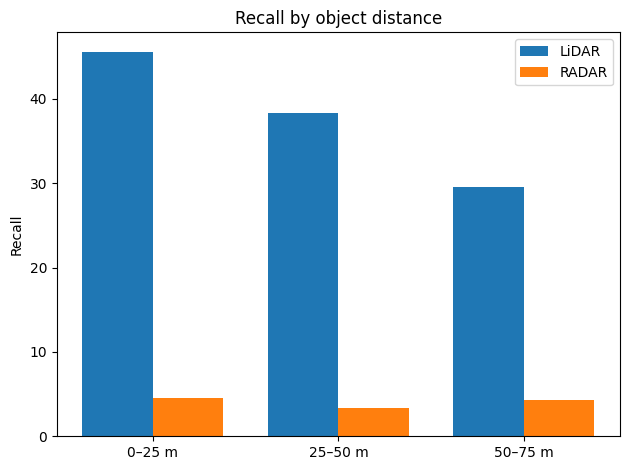

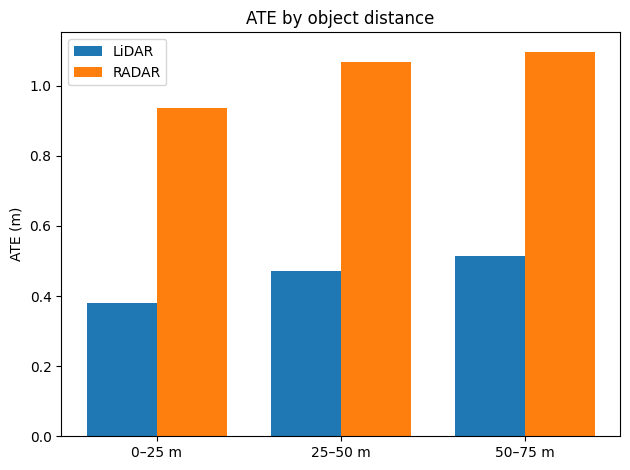

In [5]:
keys=["0-25","25-50","50-75"]; labels=["0–25 m","25–50 m","50–75 m"]
distance_df=condition_table("distance_metrics",keys,"bins",["precision","recall","f1_score","ate_m"],labels); display(fmt(distance_df))
plot_grouped(labels,{"LiDAR":[lidar["distance_metrics"]["bins"][k]["recall"] for k in keys],"RADAR":[radar["distance_metrics"]["bins"][k]["recall"] for k in keys]},"Recall by object distance","Recall",True)
plot_grouped(labels,{"LiDAR":[lidar["distance_metrics"]["bins"][k]["ate_m"] for k in keys],"RADAR":[radar["distance_metrics"]["bins"][k]["ate_m"] for k in keys]},"ATE by object distance","ATE (m)")

LiDAR recall decreases noticeably with distance. RADAR recall is much lower in absolute terms but relatively less distance-sensitive; this alone does not mean RADAR outperforms LiDAR at long range.

## 6. Performance by Object Size

,condition,LiDAR precision,LiDAR recall,LiDAR f1_score,RADAR precision,RADAR recall,RADAR f1_score
0,small,99.3%,35.4%,52.2%,98.3%,1.4%,2.8%
1,medium,88.3%,57.9%,69.9%,53.6%,5.4%,9.8%
2,large,53.1%,23.9%,33.0%,23.2%,4.8%,8.0%


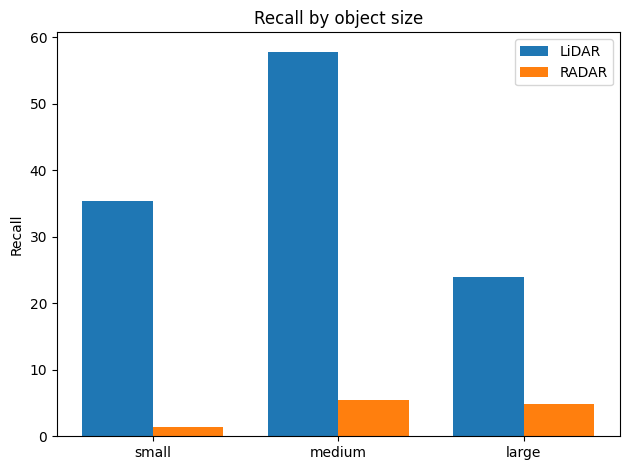

Existing global GT-volume tertile thresholds are **11.661 m³** and **17.014 m³**. Global size bins may also reflect class composition.

In [6]:
keys=["small","medium","large"]; size_df=condition_table("size_metrics",keys,"bins",["precision","recall","f1_score"]); display(fmt(size_df))
plot_grouped(keys,{"LiDAR":[lidar["size_metrics"]["bins"][k]["recall"] for k in keys],"RADAR":[radar["size_metrics"]["bins"][k]["recall"] for k in keys]},"Recall by object size","Recall",True)
display(Markdown(f"Existing global GT-volume tertile thresholds are **{lidar['size_metrics']['thresholds_m3']['small_medium']:.3f} m³** and **{lidar['size_metrics']['thresholds_m3']['medium_large']:.3f} m³**. Global size bins may also reflect class composition."))

## 7. Performance by Visibility

,condition,LiDAR gt_count,LiDAR tp,LiDAR fn,LiDAR recall,LiDAR ate_m,RADAR gt_count,RADAR tp,RADAR fn,RADAR recall,RADAR ate_m
0,1: 0–40%,15058,2239,12819,14.9%,0.470,15058,152,14906,1.0%,1.131
1,2: 41–60%,8286,2324,5962,28.0%,0.423,8286,85,8201,1.0%,1.198
2,3: 61–80%,10755,3793,6962,35.3%,0.413,10755,179,10576,1.7%,1.031
3,4: 81–100%,53682,25954,27728,48.3%,0.446,53682,2998,50684,5.6%,1.014


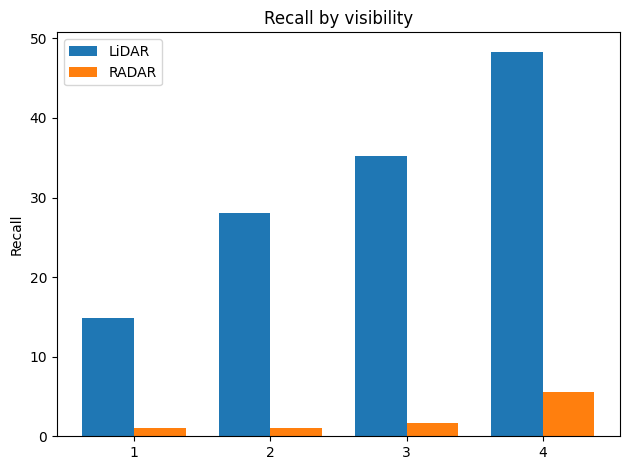

In [7]:
keys=["1","2","3","4"]; labels=["1: 0–40%","2: 41–60%","3: 61–80%","4: 81–100%"]
vdf=condition_table("visibility_metrics",keys,"levels",["gt_count","tp","fn","recall","ate_m"],labels); display(fmt(vdf))
plot_grouped(keys,{"LiDAR":[lidar["visibility_metrics"]["levels"][k]["recall"] for k in keys],"RADAR":[radar["visibility_metrics"]["levels"][k]["recall"] for k in keys]},"Recall by visibility","Recall",True)

Both pipelines perform better as visibility increases. FP attribution is unavailable at object-condition level, so precision/F1 are not invented. These results do not demonstrate RADAR robustness to severe occlusion.

## 8. Performance by Motion

,condition,LiDAR gt_count,LiDAR tp,LiDAR fn,LiDAR recall,LiDAR ate_m,RADAR gt_count,RADAR tp,RADAR fn,RADAR recall,RADAR ate_m
0,moving,67094,30196,36898,45.0%,0.456,67094,3410,63684,5.1%,1.024
1,stationary,19641,4110,15531,20.9%,0.340,19641,4,19637,0.0%,1.540
2,unknown,1046,4,1042,0.4%,0.391,1046,0,1046,0.0%,nan


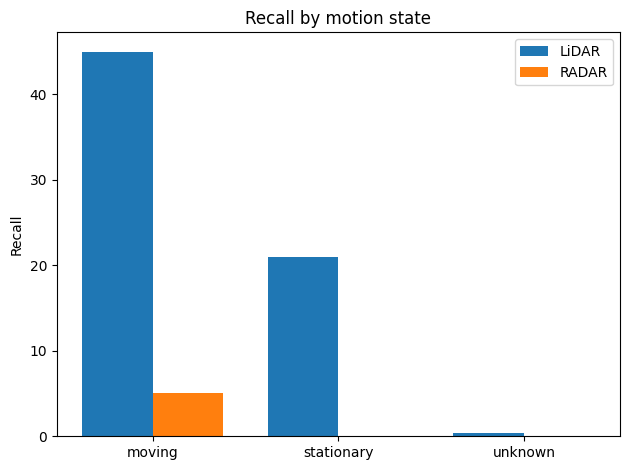

In [8]:
keys=["moving","stationary","unknown"]; mdf=condition_table("motion_metrics",keys,"states",["gt_count","tp","fn","recall","ate_m"]); display(fmt(mdf))
plot_grouped(keys,{"LiDAR":[lidar["motion_metrics"]["states"][k]["recall"] for k in keys],"RADAR":[radar["motion_metrics"]["states"][k]["recall"] for k in keys]},"Recall by motion state","Recall",True)

Both perform better for moving objects. RADAR is extremely weak for stationary objects and appears strongly biased toward moving objects; Doppler is not established as the cause by this experiment.

## 9. Performance by Weather

,condition,LiDAR sample_count,LiDAR precision,LiDAR recall,LiDAR f1_score,LiDAR ate_m,RADAR sample_count,RADAR precision,RADAR recall,RADAR f1_score,RADAR ate_m
0,clear,5793,78.1%,41.2%,54.0%,0.528,5793,47.5%,6.7%,11.8%,1.015
1,fog,395,87.8%,44.0%,58.7%,0.553,395,4.4%,1.0%,1.6%,1.166
2,overcast,1275,74.6%,33.2%,45.9%,0.422,1275,8.8%,0.7%,1.3%,1.129
3,rain,1720,86.1%,45.5%,59.5%,0.293,1720,19.7%,0.9%,1.7%,1.067
4,snow,840,80.7%,13.5%,23.1%,0.374,840,20.9%,2.2%,3.9%,1.081
5,other_weather,40,100.0%,61.0%,75.8%,0.286,40,17.1%,2.9%,5.0%,0.741


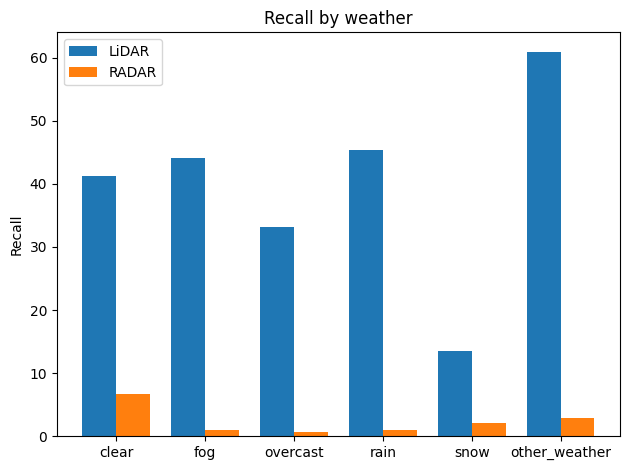

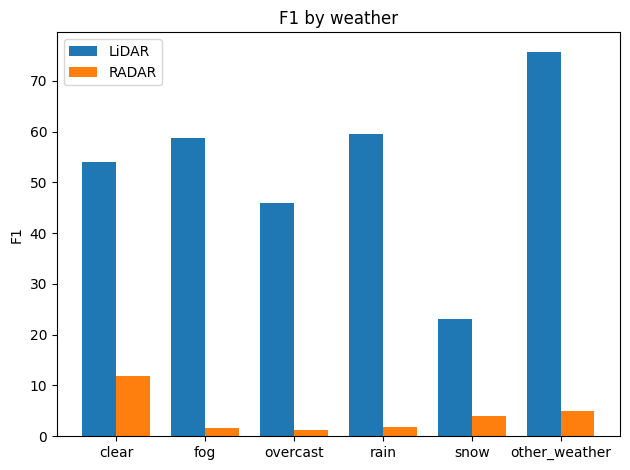

In [9]:
keys=["clear","fog","overcast","rain","snow","other_weather"]; wdf=condition_table("weather_metrics",keys,"categories",["sample_count","precision","recall","f1_score","ate_m"]); display(fmt(wdf))
for f,t,y in [("recall","Recall by weather","Recall"),("f1_score","F1 by weather","F1")]:
    plot_grouped(keys,{"LiDAR":[lidar["weather_metrics"]["categories"][k][f] for k in keys],"RADAR":[radar["weather_metrics"]["categories"][k][f] for k in keys]},t,y,True)

LiDAR remains much stronger than RADAR in the evaluated rain/fog scenes. This does not support a RADAR advantage in adverse weather. Weather may be confounded by scene composition, class, distance, visibility and other factors; other_weather is small.

## 10. Performance by Area

,condition,LiDAR precision,LiDAR recall,LiDAR f1_score,RADAR precision,RADAR recall,RADAR f1_score
0,city,84.6%,32.4%,46.9%,11.1%,0.3%,0.6%
1,highway,86.4%,45.5%,59.6%,40.6%,5.9%,10.3%
2,parking,72.8%,9.9%,17.5%,nan%,0.0%,nan%
3,residential,71.2%,30.7%,42.9%,5.6%,0.5%,0.9%
4,rural,69.9%,37.7%,48.9%,8.6%,1.2%,2.1%
5,terminal,23.9%,12.2%,16.1%,0.0%,0.0%,0.0%
6,other_area,86.1%,39.3%,53.9%,0.0%,0.0%,0.0%


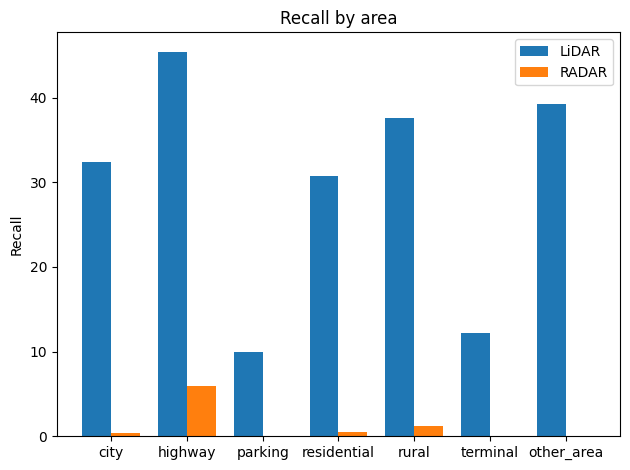

In [10]:
keys=["city","highway","parking","residential","rural","terminal","other_area"]; adf=condition_table("area_metrics",keys,"categories",["precision","recall","f1_score"]); display(fmt(adf))
plot_grouped(keys,{"LiDAR":[lidar["area_metrics"]["categories"][k]["recall"] for k in keys],"RADAR":[radar["area_metrics"]["categories"][k]["recall"] for k in keys]},"Recall by area","Recall",True)

Highway is strongest for both transferred models, but area effects may be confounded by scene/object composition.

## 11. LiDAR–RADAR Complementarity
RADAR standalone performance is much weaker than LiDAR, but RADAR may still detect objects LiDAR misses. Each GT object is assigned exactly one category: **Both**, **LiDAR only**, **RADAR only**, or **Neither**. RADAR only means missed by LiDAR but correctly detected by RADAR. **RADAR Recovery Rate = RADAR only / LiDAR misses**, distinct from total union-recall improvement.

In [7]:
o=comp["overall"]; cdf=pd.DataFrame([{"total GT":o["total_gt"],"Both":o["both"],"LiDAR only":o["lidar_only"],"RADAR only":o["radar_only"],"Neither":o["neither"],"LiDAR recall":o["lidar_recall"],"RADAR recall":o["radar_recall"],"union recall":o["union_recall"],"RADAR recovery rate":o["radar_recovery_rate"]}]); display(fmt(cdf))
imp=o["union_recall"]-o["lidar_recall"]; display(Markdown(f"RADAR recovery rate is **{o['radar_recovery_rate']:.2%}**. Union recall rises from **{o['lidar_recall']:.2%}** to **{o['union_recall']:.2%}**, a separate improvement of **{imp:.2%}** (about {100*imp:.2f} percentage points)."))

,total GT,Both,LiDAR only,RADAR only,Neither,LiDAR recall,RADAR recall,union recall,RADAR recovery rate
0,87781,2418,31892,996,52475,39.1%,3.9%,40.2%,0.019


RADAR recovery rate is **1.86%**. Union recall rises from **39.09%** to **40.22%**, a separate improvement of **1.13%** (about 1.13 percentage points).

### 11.1 Detection Outcome Distribution

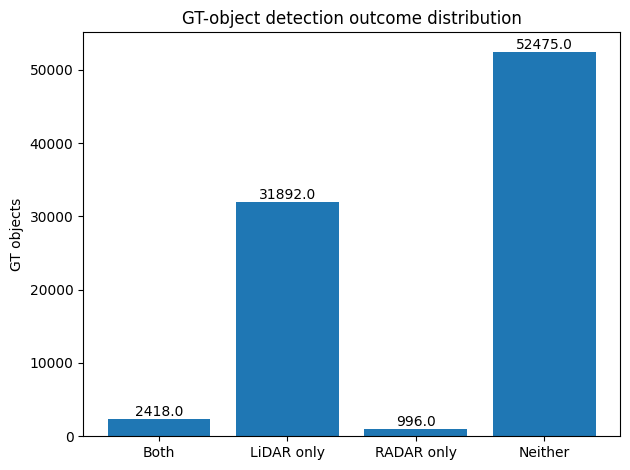

In [8]:
labels=["Both","LiDAR only","RADAR only","Neither"]
vals=[o["both"],o["lidar_only"],o["radar_only"],o["neither"]] 
plot_single(labels,vals,"GT-object detection outcome distribution","GT objects")

### 11.2 Standalone vs Union Recall

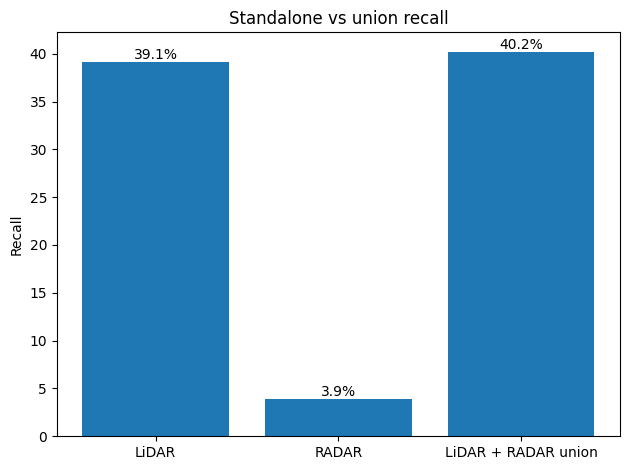

In [9]:
plot_single(["LiDAR","RADAR","LiDAR + RADAR union"],[o["lidar_recall"],o["radar_recall"],o["union_recall"]],"Standalone vs union recall","Recall",True)

### 11.3 RADAR Recovery by Class

,class,RADAR only,RADAR recovery rate
0,car,277,0.010
1,pedestrian,0,0.000
2,rider,0,0.000
3,large_vehicle,719,0.038


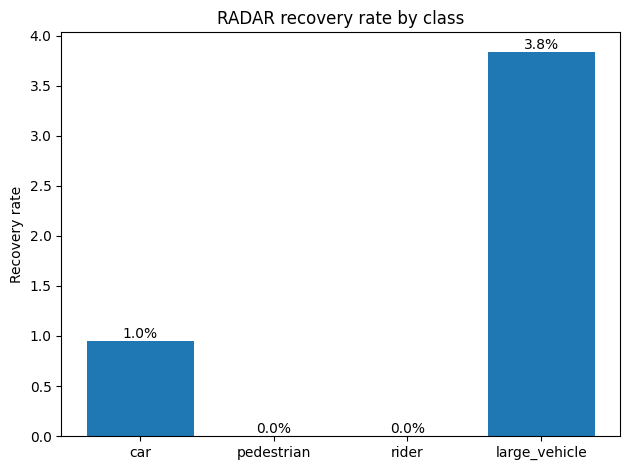

In [10]:
rows=[]
for k in classes:
    x=comp["class_breakdown"][k]; rows.append({"class":k,"RADAR only":x["radar_only"],"RADAR recovery rate":x["radar_recovery_rate"]})
ccdf=pd.DataFrame(rows); display(fmt(ccdf)); plot_single(classes,list(ccdf["RADAR recovery rate"]),"RADAR recovery rate by class","Recovery rate",True)

Large vehicles show the strongest class-level complementarity. Car recovery is small; pedestrian and rider recovery are zero.

### 11.4 RADAR Recovery by Distance

,distance,RADAR only,RADAR recovery rate,LiDAR recall,union recall
0,0–25 m,155,0.010,45.6%,46.2%
1,25–50 m,429,0.016,38.4%,39.4%
2,50–75 m,412,0.035,29.6%,32.1%


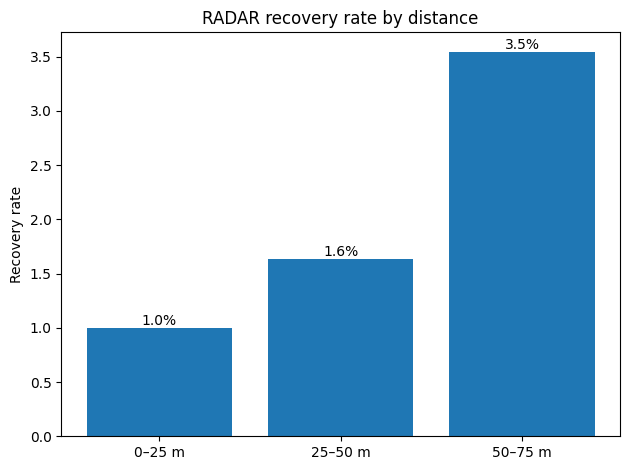

At 50–75 m, union recall rises from approximately **29.60%** LiDAR to **32.10%** LiDAR + RADAR.

In [11]:
rows=[]
for k,label in zip(["0-25","25-50","50-75"],["0–25 m","25–50 m","50–75 m"]):
    x=comp["distance_breakdown"][k]; rows.append({"distance":label,"RADAR only":x["radar_only"],"RADAR recovery rate":x["radar_recovery_rate"],"LiDAR recall":x["lidar_recall"],"union recall":x["union_recall"]})
dcdf=pd.DataFrame(rows); display(fmt(dcdf)); plot_single(list(dcdf.distance),list(dcdf["RADAR recovery rate"]),"RADAR recovery rate by distance","Recovery rate",True)
x=comp["distance_breakdown"]["50-75"]; display(Markdown(f"At 50–75 m, union recall rises from approximately **{x['lidar_recall']:.2%}** LiDAR to **{x['union_recall']:.2%}** LiDAR + RADAR."))

### 11.5 RADAR Recovery by Motion

,motion,RADAR only,RADAR recovery rate
0,moving,994,0.027
1,stationary,2,0.000
2,unknown,0,0.000


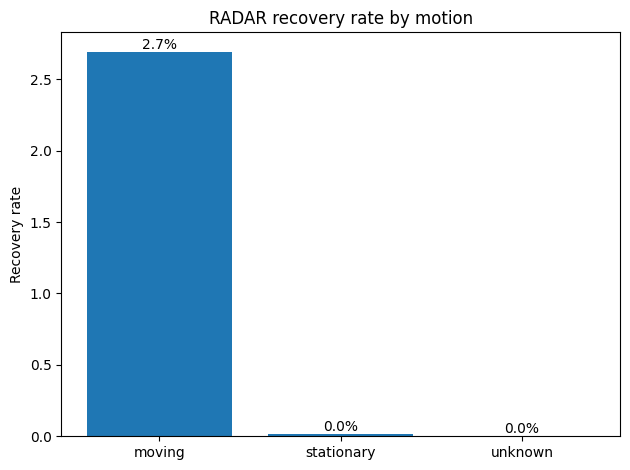

In [12]:
rows=[]
for k in ["moving","stationary","unknown"]:
    x=comp["motion_breakdown"][k]; rows.append({"motion":k,"RADAR only":x["radar_only"],"RADAR recovery rate":x["radar_recovery_rate"]})
mcdf=pd.DataFrame(rows); display(fmt(mcdf)); plot_single(list(mcdf.motion),list(mcdf["RADAR recovery rate"]),"RADAR recovery rate by motion","Recovery rate",True)

Nearly all useful RADAR-only recoveries are moving objects: 994 moving versus 2 stationary; unknown has zero.

### 11.6 RADAR Recovery by Visibility

,visibility,RADAR only,RADAR recovery rate
0,1,100,0.008
1,2,53,0.009
2,3,99,0.014
3,4,744,0.027


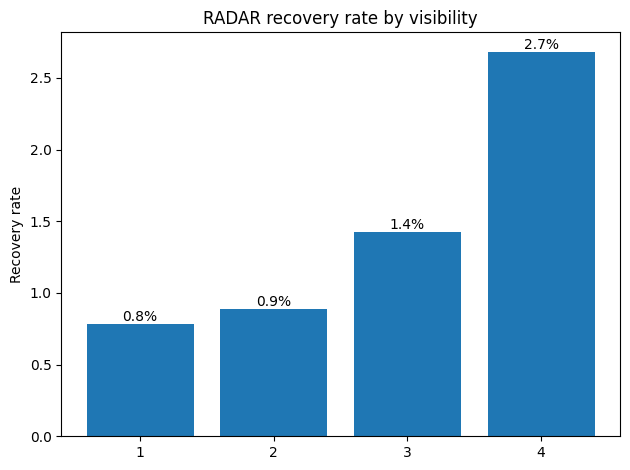

In [13]:
rows=[]
for k in ["1","2","3","4"]:
    x=comp["visibility_breakdown"][k]; rows.append({"visibility":k,"RADAR only":x["radar_only"],"RADAR recovery rate":x["radar_recovery_rate"]})
vcdf=pd.DataFrame(rows); display(fmt(vcdf)); plot_single(list(vcdf.visibility),list(vcdf["RADAR recovery rate"]),"RADAR recovery rate by visibility","Recovery rate",True)

RADAR recovery increases with visibility; this does not demonstrate strong recovery of severely occluded objects.

### 11.7 RADAR Recovery by Weather

,weather,RADAR only,RADAR recovery rate
0,clear,742,0.029
1,fog,10,0.008
2,overcast,19,0.002
3,rain,106,0.009
4,snow,118,0.020
5,other_weather,1,0.011


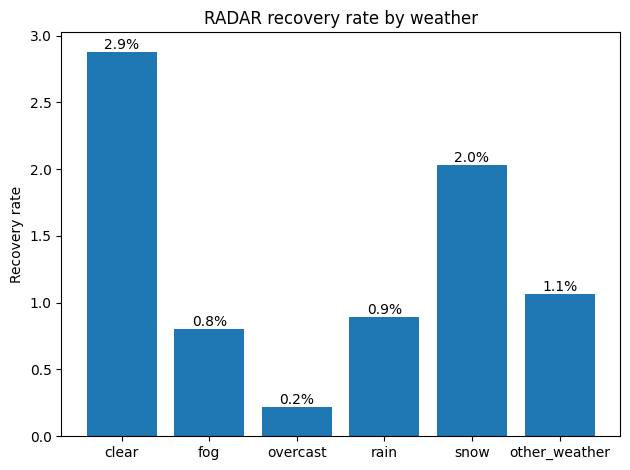

In [14]:
rows=[]
for k in ["clear","fog","overcast","rain","snow","other_weather"]:
    x=comp["weather_breakdown"][k]; rows.append({"weather":k,"RADAR only":x["radar_only"],"RADAR recovery rate":x["radar_recovery_rate"]})
wcdf=pd.DataFrame(rows); display(fmt(wcdf)); plot_single(list(wcdf.weather),list(wcdf["RADAR recovery rate"]),"RADAR recovery rate by weather","Recovery rate",True)

This experiment does not provide evidence of strong RADAR recovery advantages in rain or fog. other_weather is included but is small.

### 11.8 RADAR Recovery by Area

,area,RADAR only,RADAR recovery rate
0,city,12,0.001
1,highway,955,0.031
2,parking,0,0.000
3,residential,2,0.001
4,rural,27,0.009
5,terminal,0,0.000
6,other_area,0,0.000


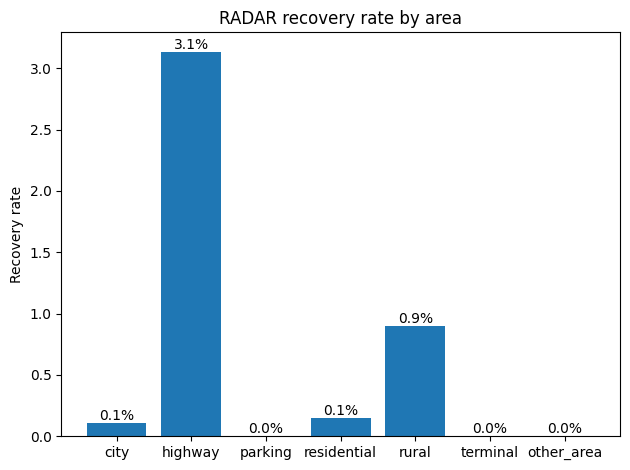

: 

In [ ]:
rows=[]
for k in ["city","highway","parking","residential","rural","terminal","other_area"]:
    x=comp["area_breakdown"][k]; rows.append({"area":k,"RADAR only":x["radar_only"],"RADAR recovery rate":x["radar_recovery_rate"]})
acdf=pd.DataFrame(rows); display(fmt(acdf)); plot_single(list(acdf.area),list(acdf["RADAR recovery rate"]),"RADAR recovery rate by area","Recovery rate",True)

Highway recovery is approximately **3.14%** with **955 RADAR-only detections**. Several other areas have zero or almost zero recovery, so useful RADAR complementarity is concentrated in highway scenes.

## 12. Key Findings and Recommendations
1. **Standalone detection:** LiDAR is substantially more effective and should remain primary.
2. **Complementarity:** RADAR recovers **996 LiDAR misses**; recovery rate is **1.86%**; union recall rises **39.09% → 40.22%**, approximately **+1.13 percentage points**.
3. **Where RADAR helps:** large vehicles, 50–75 m, moving objects, and highway scenes.
4. **Where it currently helps little:** pedestrians, riders, stationary objects, severe occlusion, fog, rain, and many urban/terminal conditions.
5. **Recommendation:** treat RADAR as supplementary rather than a LiDAR replacement. Future work should examine RADAR-specific training/fine-tuning, fusion instead of simple union, calibrated thresholds, balanced pedestrian/rider evaluation, and controls for class/distance/weather/scene composition.

This study evaluates transferred pretrained models, not intrinsic sensor capability in isolation.